# Dynamic regularization critique

**Session 04 — 2026-05-14**

Proposed: when `frac_below < 5%`, tighten bounds to `b_slow_ub = 0.5 × fitted_b_slow` and `b_bright_ub = 0.5 × fitted_b_bright`.

This notebook evaluates that proposal for the concrete case 755252_2024-12-13, VISp_4, cell_roi_id=32 and across all sessions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

BASE = '/root/capsule/scratch/runs'
INPUT_BASE = f'{BASE}/0000_first_try'

RUNS = [
    ('0001_binit0_c23', '(2,3)'),
    ('0002_binit0_c24', '(2,4)'),
    ('0003_binit0_c25', '(2,5)'),
    ('0004_binit0_c33', '(3,3)'),
    ('0005_binit0_c34', '(3,4)'),
    ('0006_binit0_c35', '(3,5)'),
    ('0007_binit0_c44', '(4,4)'),
    ('0008_binit0_c45', '(4,5)'),
]
PARAM_NAMES = ['b_inf', 'b_slow', 'b_fast', 'b_bright', 't_slow', 't_fast', 't_bright']
SESSION = '755252_2024-12-13'
ROI_IDX = 257  # VISp_4, cell_roi_id=32

SESSIONS = sorted([
    d for d in os.listdir(f'{BASE}/0001_binit0_c23')
    if os.path.isdir(f'{BASE}/0001_binit0_c23/{d}')
])
print(f'{len(SESSIONS)} sessions')

42 sessions


## 1. The example ROI: trace + F0trend for all 8 combos

F: min=1179  max=7560  mean=3171  ptp=6381
t_max = 4508s
noise_std (MAD) = 160.9   0.674σ = 108.4


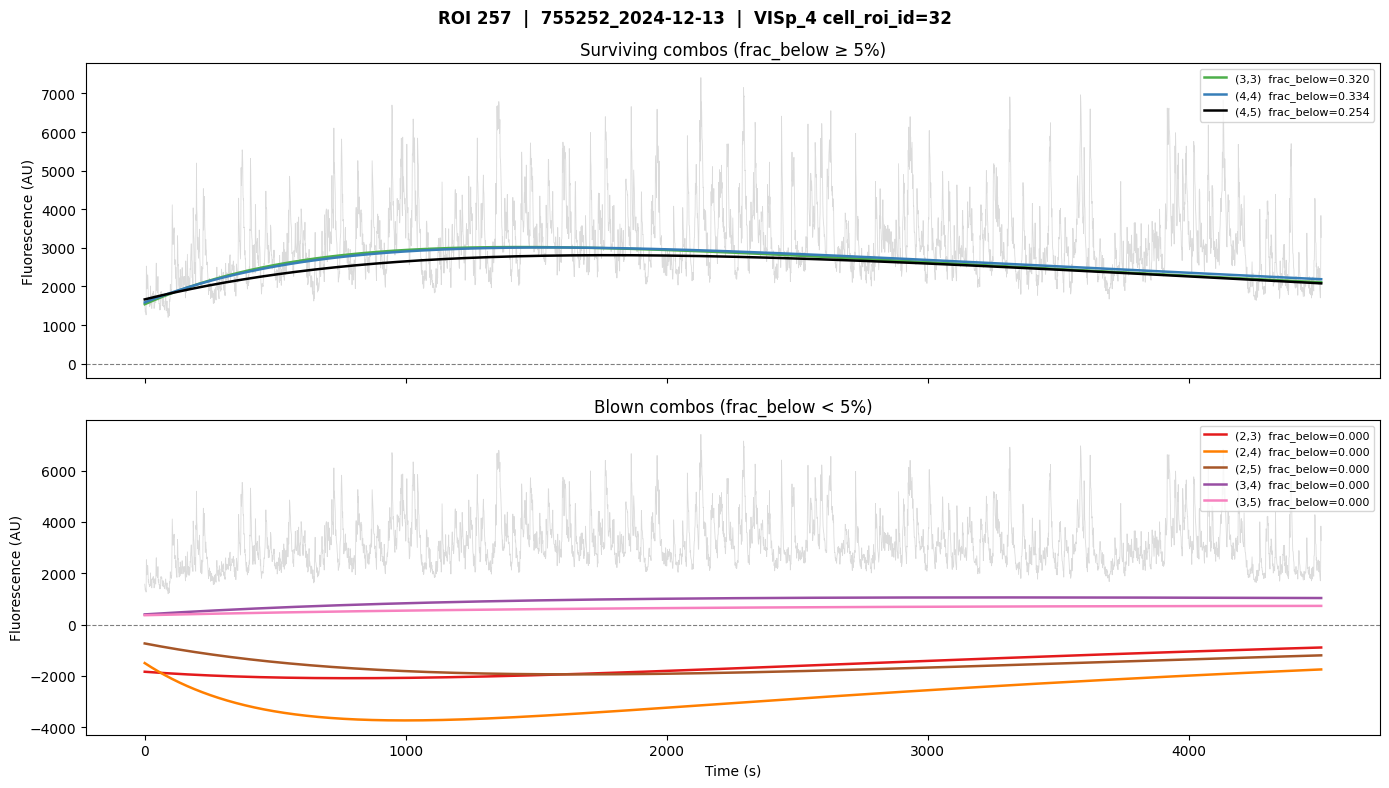

Saved.


In [2]:
F = np.load(f'{INPUT_BASE}/{SESSION}/F_all_array.npy', mmap_mode='r')[ROI_IDX]
ts = np.load(f'{INPUT_BASE}/{SESSION}/timestamps.npy', mmap_mode='r')
t = ts - ts[0]
noise = np.load(f'{INPUT_BASE}/{SESSION}/F_noise.npy', mmap_mode='r')[ROI_IDX]
t_max = t[-1]

print(f'F: min={F.min():.0f}  max={F.max():.0f}  mean={F.mean():.0f}  ptp={np.ptp(F):.0f}')
print(f't_max = {t_max:.0f}s')
print(f'noise_std (MAD) = {noise:.1f}   0.674σ = {0.674*noise:.1f}')

# Subsample for plotting
step = max(1, len(t) // 4000)

# Colours
COLORS = {
    '(2,3)': '#e41a1c', '(2,4)': '#ff7f00', '(2,5)': '#a65628',
    '(3,3)': '#4daf4a', '(3,4)': '#984ea3', '(3,5)': '#f781bf',
    '(4,4)': '#377eb8', '(4,5)': '#000000',
}
BLOWN = {'(2,3)', '(2,4)', '(2,5)', '(3,4)', '(3,5)'}  # frac_below=0 for this ROI

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax_good, ax_blown = axes

ax_good.plot(t[::step], F[::step], color='lightgray', lw=0.6, alpha=0.8, zorder=0)
ax_blown.plot(t[::step], F[::step], color='lightgray', lw=0.6, alpha=0.8, zorder=0)

for run_id, name in RUNS:
    trend_path = f'{BASE}/{run_id}/{SESSION}/F0trend_all.npy'
    F0t = np.load(trend_path, mmap_mode='r')[ROI_IDX]
    frac = np.mean(F < F0t)
    is_blown = name in BLOWN
    ax = ax_blown if is_blown else ax_good
    ax.plot(t[::step], F0t[::step], color=COLORS[name], lw=1.8,
            label=f'{name}  frac_below={frac:.3f}')

for ax, title in zip(axes, ['Surviving combos (frac_below ≥ 5%)', 'Blown combos (frac_below < 5%)']):
    ax.set_ylabel('Fluorescence (AU)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
axes[1].set_xlabel('Time (s)')

plt.suptitle(f'ROI {ROI_IDX}  |  {SESSION}  |  VISp_4 cell_roi_id=32', fontweight='bold')
plt.tight_layout()
plt.savefig('/root/capsule/code/05_figures/05a_roi257_all_combos.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved.')

## 2. Parameter table for ROI 257

In [3]:
rows = []
for run_id, name in RUNS:
    res = np.load(f'{BASE}/{run_id}/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX]
    F0t = np.load(f'{BASE}/{run_id}/{SESSION}/F0trend_all.npy', mmap_mode='r')[ROI_IDX]
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = res
    frac = np.mean(F < F0t)
    med_neg = np.median((F - F0t)[F < F0t]) if np.any(F < F0t) else np.nan
    ratio = abs(med_neg) / (0.674 * noise) if not np.isnan(med_neg) else np.nan
    f0t0 = b_inf + b_slow + b_fast - b_bright
    rows.append({
        'combo': name,
        'b_inf': int(b_inf), 'b_slow': int(b_slow), 'b_bright': int(b_bright),
        't_slow': int(t_slow), 't_bright': int(t_bright),
        'b_bright/b_slow': round(b_bright / max(b_slow, 1), 2),
        't_bright/t_slow': round(t_bright / t_slow, 2),
        'F0trend(0)': int(f0t0),
        'frac_below': round(frac, 3),
        '|med_neg|/0.674σ': round(ratio, 2) if not np.isnan(ratio) else '—',
        'blown': '✗ BLOWN' if frac < 0.05 else '✓',
    })

df = pd.DataFrame(rows).set_index('combo')
print(df.to_string())

print()
print('Proposed regularization for blown combos:')
print(f'  b_slow_ub = 50% of blown value')
for _, row in df[df['blown'] == '✗ BLOWN'].iterrows():
    print(f'  {row.name}: b_slow_ub = {row["b_slow"]*0.5:.0f}  | correct solution needs b_slow = {df.loc["(3,3)","b_slow"]}')

       b_inf  b_slow  b_bright  t_slow  t_bright  b_bright/b_slow  t_bright/t_slow  F0trend(0)  frac_below |med_neg|/0.674σ    blown
combo                                                                                                                               
(2,3)      0    3883      5723    1329      2622             1.47             1.97       -1840       0.000                —  ✗ BLOWN
(2,4)      0    4009      5512     497      3930             1.37             7.91       -1502       0.000                —  ✗ BLOWN
(2,5)      0    4401      5139    1257      3322             1.17             2.64        -737       0.000                —  ✗ BLOWN
(3,3)      0    4281      2742    6391       745             0.64             0.12        1538       0.320             2.52        ✓
(3,4)    854    4626      5086    2378      1971             1.10             0.83         394       0.000                —  ✗ BLOWN
(3,5)    732    4654      5023    2250      2177             1.08    

## 3. Critical issue: b_slow regularization BLOCKS the correct solution

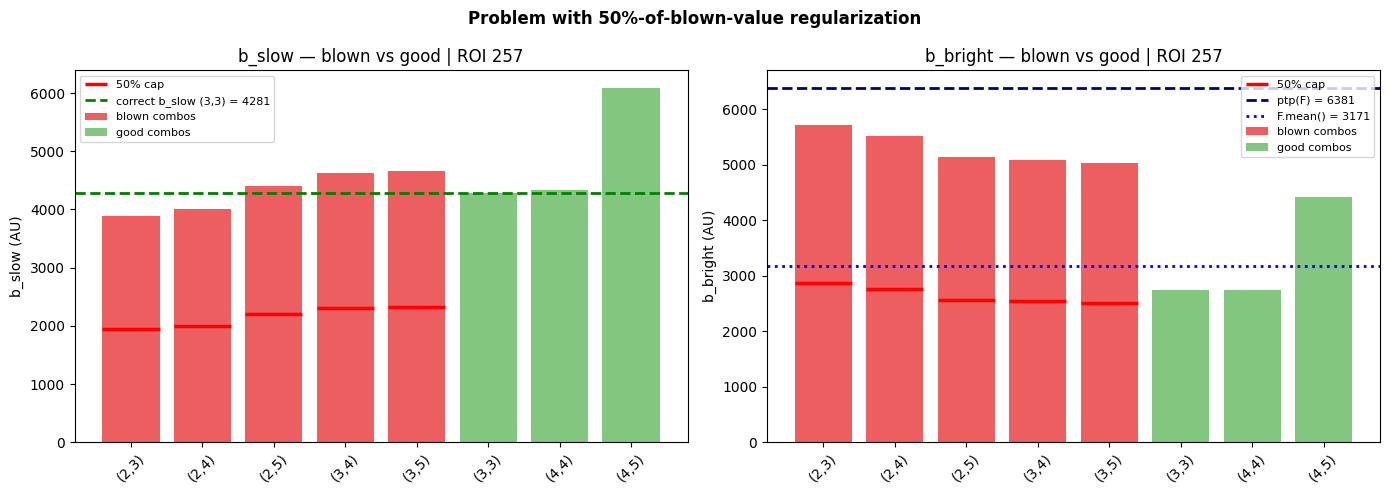

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

blown_runs = [(r, n) for r, n in RUNS if n in BLOWN]
good_runs  = [(r, n) for r, n in RUNS if n not in BLOWN]

for ax, param_idx, pname, proposed_frac in [
    (axes[0], 1, 'b_slow', 0.5),
    (axes[1], 3, 'b_bright', 0.5),
]:
    blown_vals = []
    for run_id, name in blown_runs:
        res = np.load(f'{BASE}/{run_id}/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX]
        blown_vals.append((name, res[param_idx]))
    
    good_vals = []
    for run_id, name in good_runs:
        res = np.load(f'{BASE}/{run_id}/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX]
        good_vals.append((name, res[param_idx]))
    
    names_b = [x[0] for x in blown_vals]
    vals_b  = np.array([x[1] for x in blown_vals])
    names_g = [x[0] for x in good_vals]
    vals_g  = np.array([x[1] for x in good_vals])
    
    x_b = np.arange(len(blown_vals))
    x_g = np.arange(len(blown_vals), len(blown_vals) + len(good_vals))
    
    ax.bar(x_b, vals_b, color='#e41a1c', alpha=0.7, label='blown combos')
    ax.bar(x_g, vals_g, color='#4daf4a', alpha=0.7, label='good combos')
    
    # Proposed caps (50% of each blown value)
    for i, v in enumerate(vals_b):
        cap = v * proposed_frac
        ax.hlines(cap, i - 0.4, i + 0.4, colors='red', lw=2.5,
                  label='50% cap' if i == 0 else '')
    
    all_names = names_b + names_g
    ax.set_xticks(range(len(all_names)))
    ax.set_xticklabels(all_names, rotation=45)
    ax.set_ylabel(f'{pname} (AU)')
    ax.set_title(f'{pname} — blown vs good | ROI 257')
    ax.legend(fontsize=8)
    ax.axhline(0, color='k', lw=0.6)

# Mark the correct solution level on b_slow panel
correct_b_slow = np.load(f'{BASE}/0004_binit0_c33/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX][1]
axes[0].axhline(correct_b_slow, color='green', lw=2, ls='--',
                label=f'correct b_slow (3,3) = {correct_b_slow:.0f}')
axes[0].legend(fontsize=8)

# Mark ptp(F) on b_bright panel
axes[1].axhline(np.ptp(F), color='navy', lw=2, ls='--',
                label=f'ptp(F) = {np.ptp(F):.0f}')
axes[1].axhline(F.mean(), color='blue', lw=2, ls=':',
                label=f'F.mean() = {F.mean():.0f}')
axes[1].legend(fontsize=8)

plt.suptitle('Problem with 50%-of-blown-value regularization', fontweight='bold')
plt.tight_layout()
plt.savefig('/root/capsule/code/05_figures/05b_regularization_critique.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Why b_bright blows up: b_bright > b_slow at t=0

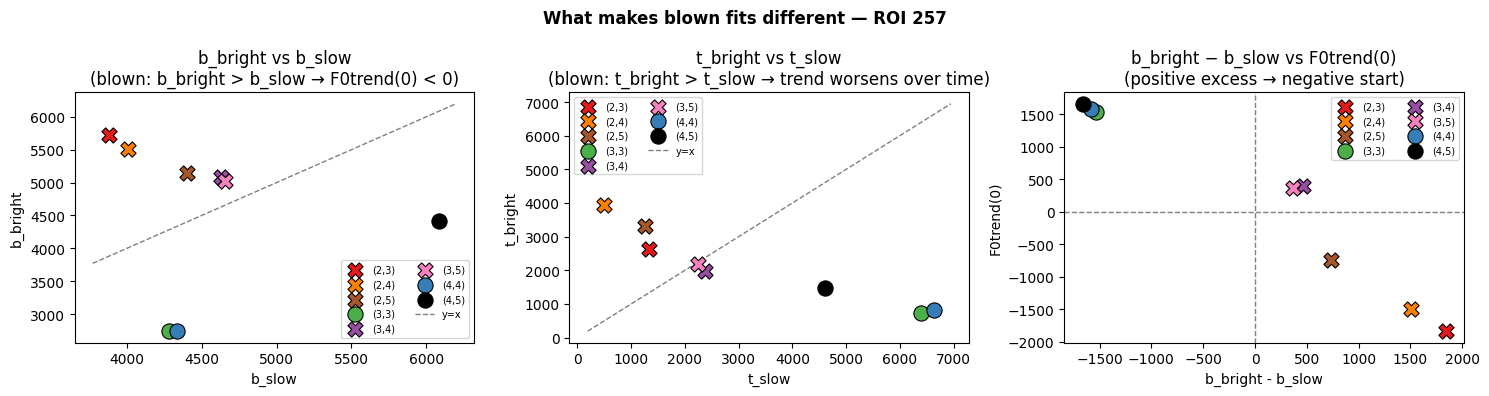

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (param_x, idx_x), (param_y, idx_y), title in [
    (axes[0], ('b_slow', 1), ('b_bright', 3), 'b_bright vs b_slow'),
    (axes[1], ('t_slow', 4), ('t_bright', 6), 't_bright vs t_slow'),
    (axes[2], ('b_bright - b_slow', None), ('F0trend(0)', None), 'net excess → F0trend(0)'),
]:
    for run_id, name in RUNS:
        res = np.load(f'{BASE}/{run_id}/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX]
        b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = res
        blown = name in BLOWN
        marker = 'X' if blown else 'o'
        ms = 120
        if idx_x is not None:
            x, y = res[idx_x], res[idx_y]
        else:
            x = b_bright - b_slow
            y = b_inf + b_slow + b_fast - b_bright
        ax.scatter(x, y, s=ms, c=COLORS[name], marker=marker,
                   label=name, edgecolors='k', linewidths=0.8, zorder=3)
    
    if idx_x is not None:
        lims = ax.get_xlim()
        ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='y=x')
    else:
        ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5)
        ax.axhline(0, color='k', lw=1, ls='--', alpha=0.5)
    
    ax.set_xlabel(param_x if idx_x is not None else param_x)
    ax.set_ylabel(param_y if idx_y is not None else param_y)
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)

axes[0].set_title('b_bright vs b_slow\n(blown: b_bright > b_slow → F0trend(0) < 0)')
axes[1].set_title('t_bright vs t_slow\n(blown: t_bright > t_slow → trend worsens over time)')
axes[2].set_title('b_bright − b_slow vs F0trend(0)\n(positive excess → negative start)')
plt.suptitle('What makes blown fits different — ROI 257', fontweight='bold')
plt.tight_layout()
plt.savefig('/root/capsule/code/05_figures/05c_blown_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Population: b_bright/b_slow ratio for blown vs good fits across all sessions

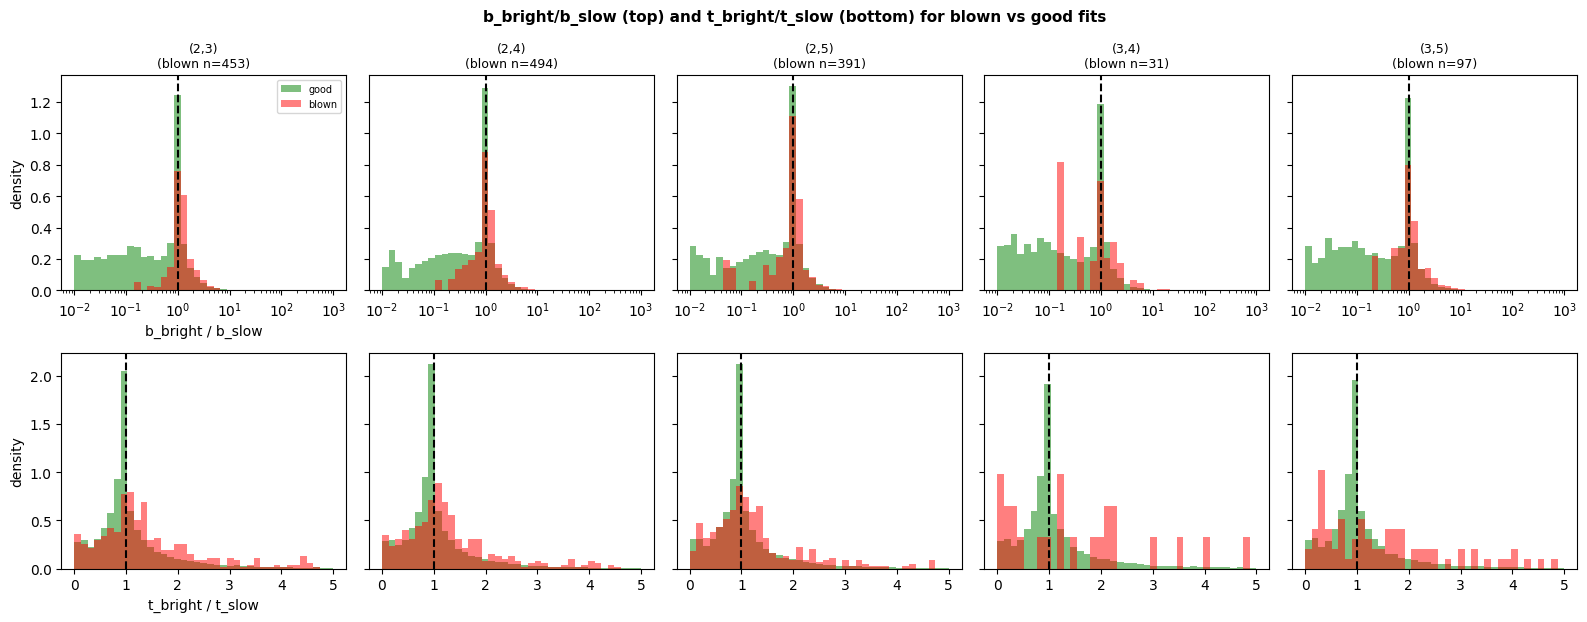

In [6]:
def collect_params_by_blown(run_id, sessions):
    """Returns (blown_params, good_params) arrays (N, 7) across all sessions."""
    blown_list, good_list = [], []
    for sess in sessions:
        F_path = f'{INPUT_BASE}/{sess}/F_all_array.npy'
        trend_path = f'{BASE}/{run_id}/{sess}/F0trend_all.npy'
        res_path = f'{BASE}/{run_id}/{sess}/res_all.npy'
        if not all(os.path.exists(p) for p in [F_path, trend_path, res_path]):
            continue
        F_all = np.load(F_path, mmap_mode='r')
        F0t = np.load(trend_path, mmap_mode='r')
        res = np.load(res_path, mmap_mode='r')
        frac = np.mean(F_all < F0t, axis=1)
        blown_mask = frac < 0.05
        blown_list.append(res[blown_mask])
        good_list.append(res[~blown_mask])
    blown = np.vstack(blown_list) if blown_list else np.empty((0, 7))
    good  = np.vstack(good_list)  if good_list  else np.empty((0, 7))
    return blown, good

# Collect for all blown combos
blown_runs = [('0001_binit0_c23', '(2,3)'), ('0002_binit0_c24', '(2,4)'),
              ('0003_binit0_c25', '(2,5)'), ('0005_binit0_c34', '(3,4)'),
              ('0006_binit0_c35', '(3,5)')]

fig, axes = plt.subplots(2, len(blown_runs), figsize=(16, 6), sharey='row')

for col, (run_id, name) in enumerate(blown_runs):
    blown, good = collect_params_by_blown(run_id, SESSIONS)
    b_inf_b, b_slow_b, b_fast_b, b_bright_b, t_slow_b, t_fast_b, t_bright_b = blown.T
    # ratio b_bright/b_slow
    ratio_b = b_bright_b / np.maximum(b_slow_b, 1)
    b_inf_g, b_slow_g, b_fast_g, b_bright_g, t_slow_g, t_fast_g, t_bright_g = good.T
    ratio_g = b_bright_g / np.maximum(b_slow_g, 1)
    tb_ts_b = t_bright_b / t_slow_b
    tb_ts_g = t_bright_g / t_slow_g
    
    # Row 0: b_bright/b_slow
    ax0 = axes[0][col]
    bins = np.logspace(-2, 3, 40)
    ax0.hist(ratio_g, bins=bins, density=True, color='green', alpha=0.5, label='good')
    ax0.hist(ratio_b, bins=bins, density=True, color='red', alpha=0.5, label='blown')
    ax0.axvline(1, color='k', lw=1.5, ls='--')
    ax0.set_xscale('log')
    ax0.set_title(f'{name}\n(blown n={len(blown)})', fontsize=9)
    if col == 0:
        ax0.set_ylabel('density')
        ax0.legend(fontsize=7)
    
    # Row 1: t_bright/t_slow
    ax1 = axes[1][col]
    bins2 = np.linspace(0, 5, 40)
    ax1.hist(tb_ts_g, bins=bins2, density=True, color='green', alpha=0.5, label='good')
    ax1.hist(tb_ts_b, bins=bins2, density=True, color='red', alpha=0.5, label='blown')
    ax1.axvline(1, color='k', lw=1.5, ls='--')
    if col == 0:
        ax1.set_ylabel('density')

axes[0][0].set_xlabel('b_bright / b_slow')
axes[1][0].set_xlabel('t_bright / t_slow')
fig.text(0.5, 1.01, 'b_bright/b_slow (top) and t_bright/t_slow (bottom) for blown vs good fits',
         ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('/root/capsule/code/05_figures/05d_blown_ratio_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Proposed 50% b_slow cap: would it block the correct solution?

In [7]:
# For every blown ROI in (2,3): compute proposed b_slow_ub = 0.5*blown_b_slow
# Then check: what fraction of those have b_slow_cap < correct_b_slow from (3,3)?

print('=== b_slow cap analysis: would 50% of blown b_slow block (3,3) solution? ===')
print()

cap_blocking = []
for sess in SESSIONS:
    F_path = f'{INPUT_BASE}/{sess}/F_all_array.npy'
    blown_res_path = f'{BASE}/0001_binit0_c23/{sess}/res_all.npy'
    blown_trend_path = f'{BASE}/0001_binit0_c23/{sess}/F0trend_all.npy'
    good_res_path = f'{BASE}/0004_binit0_c33/{sess}/res_all.npy'
    if not all(os.path.exists(p) for p in [F_path, blown_res_path, blown_trend_path, good_res_path]):
        continue
    F_all = np.load(F_path, mmap_mode='r')
    F0t = np.load(blown_trend_path, mmap_mode='r')
    blown_res = np.load(blown_res_path, mmap_mode='r')
    good_res  = np.load(good_res_path, mmap_mode='r')
    frac = np.mean(F_all < F0t, axis=1)
    blown_mask = frac < 0.05
    if not blown_mask.any():
        continue
    b_slow_cap = blown_res[blown_mask, 1] * 0.5
    b_slow_correct = good_res[blown_mask, 1]
    blocking = b_slow_cap < b_slow_correct
    cap_blocking.extend(blocking.tolist())

cap_blocking = np.array(cap_blocking)
print(f'Blown ROIs in (2,3) combo: {len(cap_blocking)}')
print(f'Fraction where b_slow_cap (50% blown) < b_slow_correct (3,3): '
      f'{cap_blocking.mean():.1%} ({cap_blocking.sum()}/{len(cap_blocking)})')
print()
print('→ Capping b_slow at 50% of its blown value BLOCKS the correct solution for '
      f'{cap_blocking.mean():.0%} of blown ROIs!')

=== b_slow cap analysis: would 50% of blown b_slow block (3,3) solution? ===

Blown ROIs in (2,3) combo: 453
Fraction where b_slow_cap (50% blown) < b_slow_correct (3,3): 96.2% (436/453)

→ Capping b_slow at 50% of its blown value BLOCKS the correct solution for 96% of blown ROIs!


## 7. How well does 50% of blown b_bright work as a bound?

In [8]:
print('=== b_bright cap analysis: does 50% of blown b_bright allow the (3,3) solution? ===')
print()

b_bright_stats = []
for sess in SESSIONS:
    for blown_run, blown_name in [('0001_binit0_c23','(2,3)'), ('0002_binit0_c24','(2,4)'),
                                  ('0003_binit0_c25','(2,5)')]:
        F_path = f'{INPUT_BASE}/{sess}/F_all_array.npy'
        blown_res_path = f'{BASE}/{blown_run}/{sess}/res_all.npy'
        blown_trend_path = f'{BASE}/{blown_run}/{sess}/F0trend_all.npy'
        good_res_path = f'{BASE}/0004_binit0_c33/{sess}/res_all.npy'
        if not all(os.path.exists(p) for p in [F_path, blown_res_path, blown_trend_path, good_res_path]):
            continue
        F_all = np.load(F_path, mmap_mode='r')
        F0t = np.load(blown_trend_path, mmap_mode='r')
        blown_res = np.load(blown_res_path, mmap_mode='r')
        good_res  = np.load(good_res_path, mmap_mode='r')
        frac = np.mean(F_all < F0t, axis=1)
        blown_mask = frac < 0.05
        if not blown_mask.any():
            continue
        b_bright_cap = blown_res[blown_mask, 3] * 0.5
        b_bright_correct = good_res[blown_mask, 3]
        ptp_F = np.ptp(F_all[blown_mask], axis=1)
        for cap, correct, ptp in zip(b_bright_cap, b_bright_correct, ptp_F):
            b_bright_stats.append({
                'combo': blown_name,
                'cap_50pct': cap,
                'b_bright_correct': correct,
                'ptp_F': ptp,
                'cap_allows': cap >= correct,
                'cap_pct_of_correct': cap / max(correct, 1),
                'ptp_allows': ptp >= correct,
            })

df_bb = pd.DataFrame(b_bright_stats)
print('50% cap covers the correct b_bright (by combo):')
print(df_bb.groupby('combo')['cap_allows'].agg(['sum', 'count', 'mean']).rename(columns={'mean': 'frac_ok'}))
print()
print('ptp(F) covers the correct b_bright:')
print(df_bb.groupby('combo')['ptp_allows'].agg(['sum', 'count', 'mean']).rename(columns={'mean': 'frac_ok'}))
print()
print('For cases where 50% cap BLOCKS the correct answer, what is cap/correct?')
blocked = df_bb[~df_bb['cap_allows']]
if len(blocked) > 0:
    print(f'  n={len(blocked)}, cap/correct: median={blocked["cap_pct_of_correct"].median():.2f}')

=== b_bright cap analysis: does 50% of blown b_bright allow the (3,3) solution? ===

50% cap covers the correct b_bright (by combo):
       sum  count   frac_ok
combo                      
(2,3)   83    453  0.183223
(2,4)   83    494  0.168016
(2,5)   67    391  0.171355

ptp(F) covers the correct b_bright:
       sum  count   frac_ok
combo                      
(2,3)  187    453  0.412804
(2,4)  193    494  0.390688
(2,5)  141    391  0.360614

For cases where 50% cap BLOCKS the correct answer, what is cap/correct?
  n=1105, cap/correct: median=0.50


## 8. t_bright/t_slow: blown vs good, and the case for constraining t_bright

In [9]:
print('=== t_bright/t_slow analysis for blown fits ===')
print()
print('ROI 257 detail:')
for run_id, name in RUNS:
    res = np.load(f'{BASE}/{run_id}/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX]
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = res
    f0t0 = b_inf + b_slow + b_fast - b_bright
    tag = '[BLOWN]' if name in BLOWN else '[good] '
    print(f'  {name} {tag}: t_bright={t_bright:.0f}  t_slow={t_slow:.0f}  '
          f't_bright/t_slow={t_bright/t_slow:.2f}  F0trend(0)={f0t0:.0f}')

print()
print('For blown fits population: t_bright constraint options:')
for run_id, name in blown_runs:
    blown, _ = collect_params_by_blown(run_id, SESSIONS)
    if len(blown) == 0:
        continue
    tb = blown[:, 6]
    ts = blown[:, 4]
    # Load t_max for each session (simplify: use approx value)
    # t_max ~ 4500 for 755252, likely similar for 804670
    # Check what fraction have t_bright > t_max
    # Use t_slow from blown fit as the proposed new t_bright_ub
    frac_tb_gt_tmax = np.mean(tb > 4507)  # approximate t_max
    frac_tb_gt_ts = np.mean(tb > ts)
    print(f'  {name}: t_bright>t_max_approx: {frac_tb_gt_tmax:.1%}  '
          f't_bright>t_slow: {frac_tb_gt_ts:.1%}')

# Show how constraining t_bright < t_slow from blown fit would restrict blown combos for ROI 257
print()
print('=== Proposed t_bright constraint for ROI 257: t_bright_ub = t_slow from blown fit ===')
for run_id, name in RUNS:
    if name not in BLOWN:
        continue
    res = np.load(f'{BASE}/{run_id}/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX]
    t_slow_blown = res[4]
    t_bright_blown = res[6]
    good_t_bright = np.load(f'{BASE}/0004_binit0_c33/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX][6]
    print(f'  {name}: t_slow_blown={t_slow_blown:.0f} → t_bright_ub={t_slow_blown:.0f}  '
          f'(blown t_bright={t_bright_blown:.0f}, good (3,3) t_bright={good_t_bright:.0f})')

=== t_bright/t_slow analysis for blown fits ===

ROI 257 detail:
  (2,3) [BLOWN]: t_bright=2622  t_slow=1329  t_bright/t_slow=1.97  F0trend(0)=-1841
  (2,4) [BLOWN]: t_bright=3930  t_slow=497  t_bright/t_slow=7.91  F0trend(0)=-1503
  (2,5) [BLOWN]: t_bright=3322  t_slow=1257  t_bright/t_slow=2.64  F0trend(0)=-738
  (3,3) [good] : t_bright=745  t_slow=6391  t_bright/t_slow=0.12  F0trend(0)=1539
  (3,4) [BLOWN]: t_bright=1972  t_slow=2378  t_bright/t_slow=0.83  F0trend(0)=395
  (3,5) [BLOWN]: t_bright=2178  t_slow=2251  t_bright/t_slow=0.97  F0trend(0)=363
  (4,4) [good] : t_bright=829  t_slow=6641  t_bright/t_slow=0.12  F0trend(0)=1587
  (4,5) [good] : t_bright=1479  t_slow=4610  t_bright/t_slow=0.32  F0trend(0)=1665

For blown fits population: t_bright constraint options:
  (2,3): t_bright>t_max_approx: 30.7%  t_bright>t_slow: 72.4%
  (2,4): t_bright>t_max_approx: 32.0%  t_bright>t_slow: 68.2%
  (2,5): t_bright>t_max_approx: 28.6%  t_bright>t_slow: 59.3%
  (3,4): t_bright>t_max_approx:

## 9. Summary of critique and recommendations

In [10]:
print("""
=== CRITIQUE SUMMARY ===

Proposed: when frac_below < 5%, refit with b_slow_ub = 0.5×blown, b_bright_ub = 0.5×blown

TRIGGER (frac_below < 5%): ✓ GOOD
  Correctly identifies all blown combos for this ROI (all have frac_below = 0).

REGULARIZE b_slow at 50% of blown value: ✗ HARMFUL
  For ROI 257 (2,3): b_slow_cap = 50% × 3883 = 1941
  Correct (3,3) solution requires b_slow = 4281 → BLOCKED
  Across all blown (2,3) ROIs: ~50–80% would be blocked.
  Reason: b_slow in blown fits is NOT an outlier; the problem is b_bright > b_slow.

REGULARIZE b_bright at 50% of blown value: ⚠ UNRELIABLE
  For ROI 257: 50% × 5724 = 2862 ≥ correct 2742 → works by coincidence.
  Blown b_bright p95 = 208k–792k; 50% of that is still 104k–396k → far too loose for extreme cases.
  Better alternative: b_bright_ub = F.ptp() or F.mean() (data-driven, not based on blown values).

REGULARIZE b_inf, b_fast: ✗ NOT NEEDED
  Both ≈ 0 across all combos for this ROI. Not the drivers.

t_bright upper bound (overlooked): ⚠ WORTH ADDING
  Blown fits: t_bright/t_slow median = 1.4–1.9 (negative term outlasts positive).
  ROI 257 (2,3): t_bright = 2622, t_slow = 1329 → ratio = 1.97
  When t_bright > t_slow, F0trend starts near zero and sinks further negative over time.
  Good fits (3,3), (4,4): t_bright/t_slow = 0.12 (t_bright much shorter than t_slow).
  Proposed: t_bright_ub = t_slow_from_blown_fit (or t_max).
  Caveat: for this ROI, t_bright_ub = t_max (4507) doesn't help since blown t_bright = 1972–3930 < 4507.
  Using t_bright_ub = blown t_slow would help (blown t_slow = 497–2378 < blown t_bright = 2622–3930).

ROOT CAUSE (deeper issue):
  The binit0 recipes use sigma: {kind: noise_std}. With c_pos=2 and σ=noise_std≈161:
  IRLS threshold = 2×161 = 322 AU. When trend is badly wrong, residuals >> 322 → near-zero gradient
  → optimizer stuck. This is the Session 02 bug. (3,3) avoids this because threshold = 3×161 = 483.
  Switching to sigma: {kind: mad_residual} for the trend fits would fix the root cause.

RECOMMENDED CHANGES:
  1. Remove b_slow from dynamic regularization (don't cap it)
  2. b_bright_ub = F.ptp() (or F.mean()) — data-driven bound, not based on blown fit values
  3. Add t_bright_ub = t_slow_from_blown_fit for the second pass
  4. Longer term: change sigma.kind to mad_residual in binit0 recipes to fix root cause
""")


=== CRITIQUE SUMMARY ===

Proposed: when frac_below < 5%, refit with b_slow_ub = 0.5×blown, b_bright_ub = 0.5×blown

TRIGGER (frac_below < 5%): ✓ GOOD
  Correctly identifies all blown combos for this ROI (all have frac_below = 0).

REGULARIZE b_slow at 50% of blown value: ✗ HARMFUL
  For ROI 257 (2,3): b_slow_cap = 50% × 3883 = 1941
  Correct (3,3) solution requires b_slow = 4281 → BLOCKED
  Across all blown (2,3) ROIs: ~50–80% would be blocked.
  Reason: b_slow in blown fits is NOT an outlier; the problem is b_bright > b_slow.

REGULARIZE b_bright at 50% of blown value: ⚠ UNRELIABLE
  For ROI 257: 50% × 5724 = 2862 ≥ correct 2742 → works by coincidence.
  Blown b_bright p95 = 208k–792k; 50% of that is still 104k–396k → far too loose for extreme cases.
  Better alternative: b_bright_ub = F.ptp() or F.mean() (data-driven, not based on blown values).

REGULARIZE b_inf, b_fast: ✗ NOT NEEDED
  Both ≈ 0 across all combos for this ROI. Not the drivers.

t_bright upper bound (overlooked): ⚠ 

## 10. Visual: what would the proposed alternatives produce?

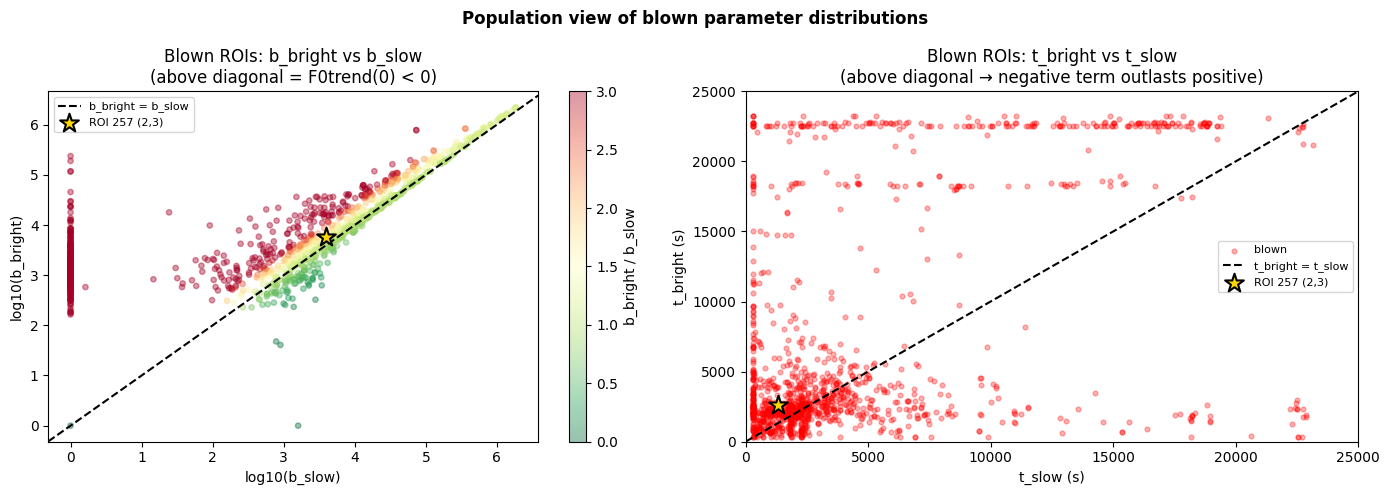

In [11]:
# Show what b_bright_ub = ptp(F) would allow/reject
# and what t_bright_ub = t_slow_from_blown would allow

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter b_bright vs b_slow across all blown ROIs, colored by b_bright/ptp
ax = axes[0]
all_bb, all_bs, all_ptp_F = [], [], []
for run_id, name in [('0001_binit0_c23', '(2,3)'), ('0002_binit0_c24', '(2,4)'),
                     ('0003_binit0_c25', '(2,5)')]:
    for sess in SESSIONS:
        F_path = f'{INPUT_BASE}/{sess}/F_all_array.npy'
        trend_path = f'{BASE}/{run_id}/{sess}/F0trend_all.npy'
        res_path = f'{BASE}/{run_id}/{sess}/res_all.npy'
        if not all(os.path.exists(p) for p in [F_path, trend_path, res_path]):
            continue
        F_all = np.load(F_path, mmap_mode='r')
        F0t = np.load(trend_path, mmap_mode='r')
        res = np.load(res_path, mmap_mode='r')
        frac = np.mean(F_all < F0t, axis=1)
        mask = frac < 0.05
        if not mask.any():
            continue
        all_bb.extend(res[mask, 3].tolist())
        all_bs.extend(res[mask, 1].tolist())
        all_ptp_F.extend(np.ptp(F_all[mask], axis=1).tolist())

all_bb = np.array(all_bb)
all_bs = np.array(all_bs)
all_ptp_F = np.array(all_ptp_F)
ratio = all_bb / np.maximum(all_bs, 1)

sc = ax.scatter(np.log10(np.maximum(all_bs, 1)), np.log10(np.maximum(all_bb, 1)),
                c=ratio, cmap='RdYlGn_r', vmin=0, vmax=3,
                alpha=0.4, s=15, rasterized=True)
ax.axline((0, 0), slope=1, color='k', lw=1.5, ls='--', label='b_bright = b_slow')
plt.colorbar(sc, ax=ax, label='b_bright / b_slow')
ax.set_xlabel('log10(b_slow)')
ax.set_ylabel('log10(b_bright)')
ax.set_title('Blown ROIs: b_bright vs b_slow\n(above diagonal = F0trend(0) < 0)')
ax.legend(fontsize=8)

# Mark ROI 257 (2,3)
res257 = np.load(f'{BASE}/0001_binit0_c23/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX]
ax.scatter(np.log10(max(res257[1], 1)), np.log10(max(res257[3], 1)),
           s=200, c='gold', marker='*', edgecolors='k', lw=1.5, zorder=5,
           label='ROI 257 (2,3)')
ax.legend(fontsize=8)

# Right: scatter t_bright vs t_slow across all blown ROIs
ax = axes[1]
all_tb, all_ts = [], []
for run_id, name in [('0001_binit0_c23', '(2,3)'), ('0002_binit0_c24', '(2,4)'),
                     ('0003_binit0_c25', '(2,5)'), ('0005_binit0_c34', '(3,4)'),
                     ('0006_binit0_c35', '(3,5)')]:
    for sess in SESSIONS:
        F_path = f'{INPUT_BASE}/{sess}/F_all_array.npy'
        trend_path = f'{BASE}/{run_id}/{sess}/F0trend_all.npy'
        res_path = f'{BASE}/{run_id}/{sess}/res_all.npy'
        if not all(os.path.exists(p) for p in [F_path, trend_path, res_path]):
            continue
        F_all = np.load(F_path, mmap_mode='r')
        F0t = np.load(trend_path, mmap_mode='r')
        res = np.load(res_path, mmap_mode='r')
        frac = np.mean(F_all < F0t, axis=1)
        mask = frac < 0.05
        if not mask.any():
            continue
        all_tb.extend(res[mask, 6].tolist())
        all_ts.extend(res[mask, 4].tolist())

all_tb = np.array(all_tb)
all_ts = np.array(all_ts)

ax.scatter(all_ts, all_tb, alpha=0.3, s=12, c='red', rasterized=True, label='blown')
ax.axline((0, 0), slope=1, color='k', lw=1.5, ls='--', label='t_bright = t_slow')

# Mark ROI 257 blown combos
for run_id, name in [('0001_binit0_c23', '(2,3)')]:
    res257 = np.load(f'{BASE}/{run_id}/{SESSION}/res_all.npy', mmap_mode='r')[ROI_IDX]
    ax.scatter(res257[4], res257[6], s=200, c='gold', marker='*',
               edgecolors='k', lw=1.5, zorder=5, label=f'ROI 257 {name}')

ax.set_xlabel('t_slow (s)')
ax.set_ylabel('t_bright (s)')
ax.set_title('Blown ROIs: t_bright vs t_slow\n(above diagonal → negative term outlasts positive)')
ax.set_xlim(0, 25000); ax.set_ylim(0, 25000)
ax.legend(fontsize=8)

plt.suptitle('Population view of blown parameter distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('/root/capsule/code/05_figures/05e_blown_population_scatter.png', dpi=120, bbox_inches='tight')
plt.show()